In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from tqdm.notebook import tqdm
from scipy.optimize import minimize

#! conda install -c conda-forge yfinance
#! conda install -c anaconda pandas-datareader
import yfinance as yf
yf.pdr_override()
from pandas_datareader import data as pdr

# Get the data

In [2]:
# List of stocks in portfolio
stocks = ['AAPL', 'AMZN','MSFT','GOOG', 'NVDA', 'F']

# Get daily price data for each of the stocks in the portfolio since 2010
prices = pdr.get_data_yahoo(stocks, start='2010-01-01')['Adj Close']
prices.sort_index(inplace=True)
returns = prices.pct_change()
print(returns.head())

# For simplicity, we consirer the risk free rate to be 5% annual
rf = 5/100

[*********************100%***********************]  6 of 6 completed
                AAPL      AMZN         F      GOOG      MSFT      NVDA
Date                                                                  
2010-01-04       NaN       NaN       NaN       NaN       NaN       NaN
2010-01-05  0.001729  0.005900  0.066148 -0.004404  0.000323  0.014603
2010-01-06 -0.015906 -0.018116  0.037409 -0.025209 -0.006137  0.006396
2010-01-07 -0.001848 -0.017013  0.025506 -0.023280 -0.010400 -0.019597
2010-01-08  0.006648  0.027077  0.002573  0.013331  0.006896  0.002161


## Calculate mean daily return and covariance of daily returns

In [3]:
mean_returns = returns.mean()
cov_matrix = returns.cov()
print('_______\nMean Daily Returns:\n' +str(mean_returns))
print('\n_______\nCovariance Matrix:\n' +str(cov_matrix))

_______
Mean Daily Returns:
AAPL    0.001125
AMZN    0.001040
F       0.000447
GOOG    0.000701
MSFT    0.000872
NVDA    0.001601
dtype: float64

_______
Covariance Matrix:
          AAPL      AMZN         F      GOOG      MSFT      NVDA
AAPL  0.000327  0.000185  0.000149  0.000175  0.000177  0.000259
AMZN  0.000185  0.000437  0.000147  0.000217  0.000194  0.000277
F     0.000149  0.000147  0.000461  0.000143  0.000142  0.000239
GOOG  0.000175  0.000217  0.000143  0.000296  0.000184  0.000250
MSFT  0.000177  0.000194  0.000142  0.000184  0.000270  0.000266
NVDA  0.000259  0.000277  0.000239  0.000250  0.000266  0.000794


# First way: Creating random portfolios and calculate means and variances

In [4]:
def random_weigths(nb_weights):
    weights = np.array(np.random.random(nb_weights))
    weights /= np.sum(weights) #make sure they sum to 1
    return weights

def portfolio_annualised_performance(weights, mean_returns, cov_matrix):
    #Convert to Matrices for simplicity
    C = np.asmatrix(cov_matrix)
    p = np.asmatrix(mean_returns)
    w = np.asmatrix(weights)
    
    # Note that the 252 is to annualize
    ret = w * p.T * 252
    stdev = np.sqrt(w * C * w.T) * np.sqrt(252)
    sharpe = ((ret-rf)/stdev)
    
    return ret.item(), stdev.item(), sharpe.item()

In [5]:
# set number of runs of random portfolio weights
nb_random_portfolios = 20000
portfolios = {'Returns':[], 'StDev':[], 'Sharpe':[]}

for i in tqdm(range(nb_random_portfolios)):
    # Create random weights for portfolio holdings
    weights = random_weigths(len(stocks))
    
    # Portfolio return, volatility (annual) and sharpe
    ret, stdev, sharpe = portfolio_annualised_performance(weights, mean_returns, cov_matrix)
    
    #Store the results
    portfolios['Returns'].append(ret)
    portfolios['StDev'].append(stdev)
    portfolios['Sharpe'].append(sharpe)


  0%|          | 0/20000 [00:00<?, ?it/s]

## Now, we can plot the efficient frontier

In [6]:
#Find the max Sharpe ratio (used in the plot)
max_sharpe_port = portfolios['Sharpe'].index(max(portfolios['Sharpe']))
max_sharpe_mean, max_sharpe_stdev = portfolios['Returns'][max_sharpe_port], portfolios['StDev'][max_sharpe_port]
print('Max Sharpe Ratio:', max(portfolios['Sharpe']))

Max Sharpe Ratio: 0.9229067428169283


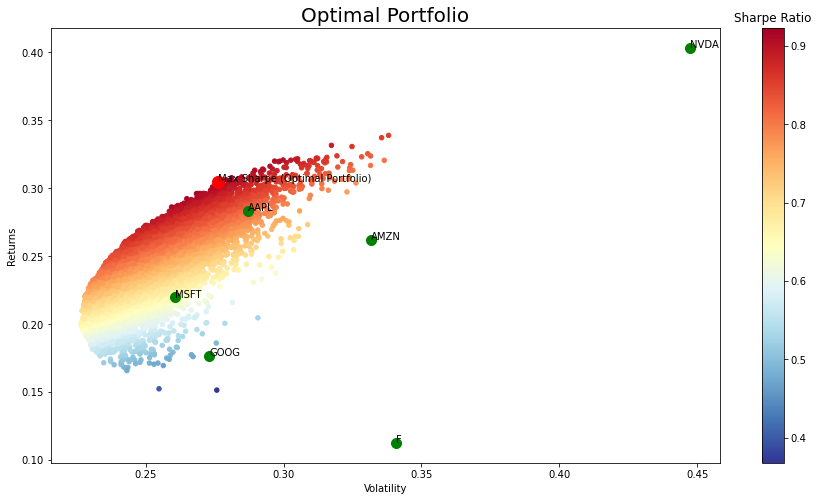

In [7]:
#Create scatter plot coloured by Sharpe Ratio
fig, ax = plt.subplots(figsize = (15,8))
h = ax.scatter(portfolios['StDev'],portfolios['Returns'],c=portfolios['Sharpe'],cmap='RdYlBu_r', s=20)
ax.set_xlabel('Volatility')
ax.set_ylabel('Returns')
clb = fig.colorbar(h)
clb.ax.set_title('Sharpe Ratio')
ax.scatter(max_sharpe_stdev,max_sharpe_mean,color='r',s=150)
ax.annotate('Max Sharpe (Optimal Portfolio)', (max_sharpe_stdev,max_sharpe_mean))

#Show the location of the original stocks
for stock in stocks:
    index = cov_matrix.index.get_loc(stock)
    ax.annotate(stock, (np.sqrt(cov_matrix[stock][index])* np.sqrt(252),mean_returns[index]* 252))
    ax.scatter(np.sqrt(cov_matrix[stock][index])* np.sqrt(252),mean_returns[index]* 252,color='g',s=100)

ax.set_title('Optimal Portfolio', fontsize=20)
plt.show()

# Second Way: By optimization

In [8]:
def portfolio_return(weights):
    return portfolio_annualised_performance(weights, mean_returns, cov_matrix)[0]

def portfolio_volatility(weights, mean_returns, cov_matrix):
    return portfolio_annualised_performance(weights, mean_returns, cov_matrix)[1]

def min_variance(mean_returns, cov_matrix, target_returns):
    # For a given return, we want to find the portfolio that has the minimum variance 
    num_assets = len(mean_returns)
    args = (mean_returns, cov_matrix) 
    constraints = (
        {'type': 'eq', 'fun': lambda x: portfolio_return(x) - target_returns}, #We want the returns the ones given
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})                        #We want the weights to sum up to one 
    bounds = tuple((0.0,1.0) for asset in range(num_assets))                   #Weights must be between 0 and 1
    starting_values = num_assets*[1./num_assets,]                              #Starting values are 0.25 of each of the 4 assets

    result = minimize(portfolio_volatility, starting_values, args=args,
                        method='SLSQP', bounds=bounds, constraints=constraints)
    return result

def efficient_frontier(mean_returns, cov_matrix, returns_range):
    efficients = []
    for ret in tqdm(returns_range):
        efficients.append(min_variance(mean_returns, cov_matrix, ret))
    return efficients

In [9]:
nb_portfolios = 2000
target_returns = np.linspace(mean_returns.min()*252, mean_returns.max()*252, nb_portfolios)
efficient_portfolios = efficient_frontier(mean_returns, cov_matrix, target_returns)

  0%|          | 0/2000 [00:00<?, ?it/s]

## Now, we plot the efficient frontier

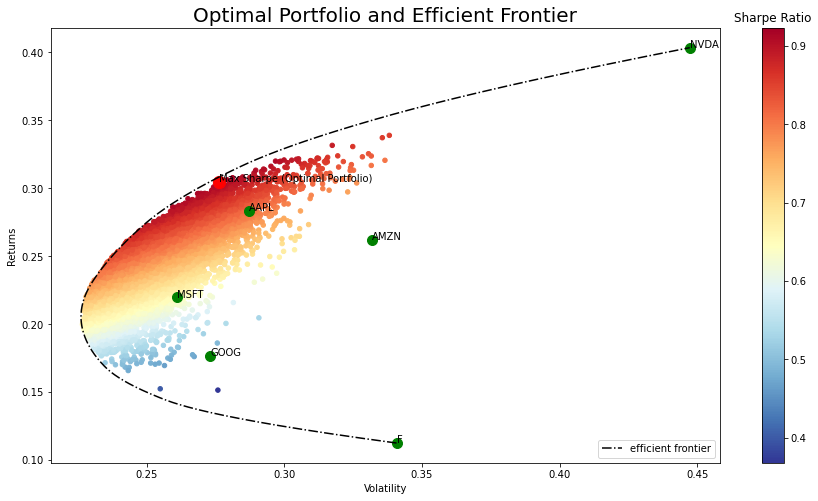

In [10]:
fig, ax = plt.subplots(figsize = (15,8))
ax.plot([p['fun'] for p in efficient_portfolios], target_returns, linestyle='-.', color='black', label='efficient frontier')

h = ax.scatter(portfolios['StDev'],portfolios['Returns'],c=portfolios['Sharpe'],cmap='RdYlBu_r', s=20)
ax.set_xlabel('Volatility')
ax.set_ylabel('Returns')
clb = fig.colorbar(h)
clb.ax.set_title('Sharpe Ratio')
ax.scatter(max_sharpe_stdev,max_sharpe_mean,color='r',s=150)
ax.annotate('Max Sharpe (Optimal Portfolio)', (max_sharpe_stdev,max_sharpe_mean))
ax.legend(loc = 'lower right')

#Show the location of the original stocks
for stock in stocks:
    index = cov_matrix.index.get_loc(stock)
    ax.annotate(stock, (np.sqrt(cov_matrix[stock][index])* np.sqrt(252),mean_returns[index]* 252))
    ax.scatter(np.sqrt(cov_matrix[stock][index])* np.sqrt(252),mean_returns[index]* 252,color='g',s=100)

ax.set_title('Optimal Portfolio and Efficient Frontier', fontsize=20)
plt.show()

# Capital Market Line

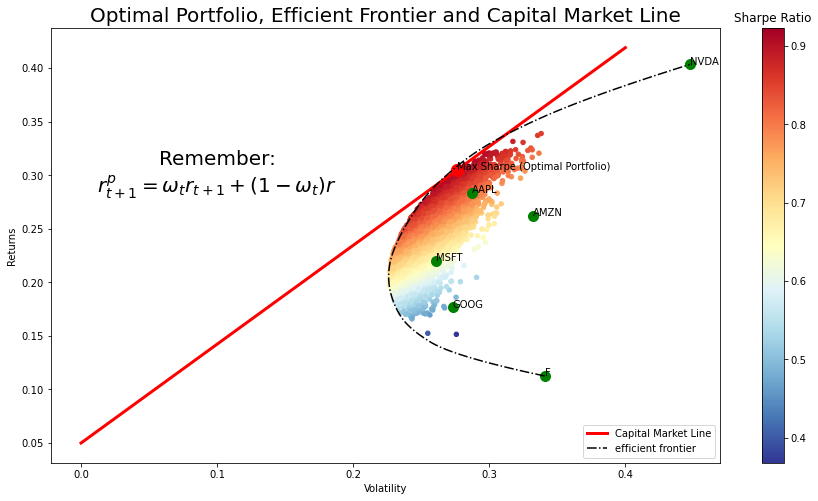

In [11]:
fig, ax = plt.subplots(figsize = (15,8))
slope = (max_sharpe_mean-rf)/ max_sharpe_stdev
x1 = np.linspace(ax.get_xlim()[0],0.4,100)
line = ax.plot(x1, x1*slope+rf, scaley=False, scalex=False, lw=3, color='r', label="Capital Market Line")

ax.plot([p['fun'] for p in efficient_portfolios], target_returns, linestyle='-.', color='black', label='efficient frontier')

h = ax.scatter(portfolios['StDev'],portfolios['Returns'],c=portfolios['Sharpe'],cmap='RdYlBu_r', s=20)
ax.set_xlabel('Volatility')
ax.set_ylabel('Returns')
clb = fig.colorbar(h)
clb.ax.set_title('Sharpe Ratio')
ax.scatter(max_sharpe_stdev,max_sharpe_mean,color='r',s=150)
ax.annotate('Max Sharpe (Optimal Portfolio)', (max_sharpe_stdev,max_sharpe_mean))
ax.legend(loc = 'lower right')

#Show the location of the original stocks
for stock in stocks:
    index = cov_matrix.index.get_loc(stock)
    ax.annotate(stock, (np.sqrt(cov_matrix[stock][index])* np.sqrt(252),mean_returns[index]* 252))
    ax.scatter(np.sqrt(cov_matrix[stock][index])* np.sqrt(252),mean_returns[index]* 252,color='g',s=100)

ax.legend(loc = 'lower right')
ax.set_title('Optimal Portfolio, Efficient Frontier and Capital Market Line', fontsize=20)

text = 'Remember:\n$r^p_{t+1} = \omega_t r_{t+1} + (1-\omega_t) r$'
ax.text(0.1, 0.3, text, ha="center", va="center", fontsize=20)

plt.show()

### Zooming in:

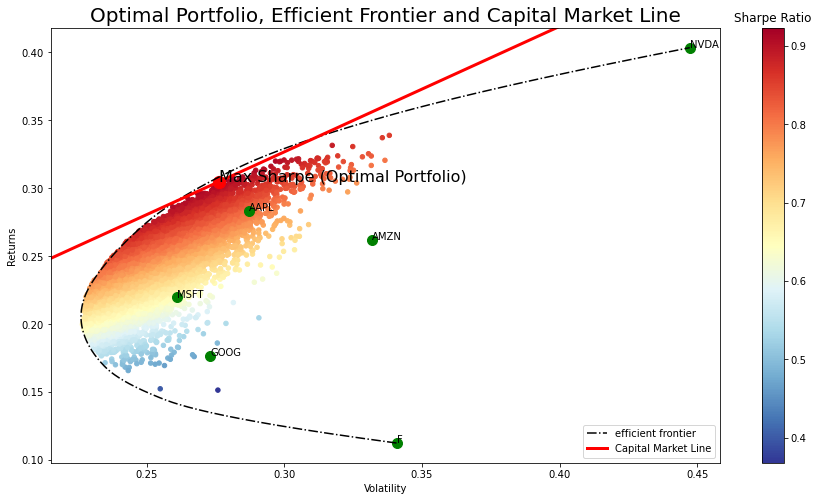

In [12]:
fig, ax = plt.subplots(figsize = (15,8))
ax.plot([p['fun'] for p in efficient_portfolios], target_returns, linestyle='-.', color='black', label='efficient frontier')

h = ax.scatter(portfolios['StDev'],portfolios['Returns'],c=portfolios['Sharpe'],cmap='RdYlBu_r', s=20)
ax.set_xlabel('Volatility')
ax.set_ylabel('Returns')
clb = fig.colorbar(h)
clb.ax.set_title('Sharpe Ratio')
ax.scatter(max_sharpe_stdev,max_sharpe_mean,color='r',s=150)
ax.annotate('Max Sharpe (Optimal Portfolio)', (max_sharpe_stdev,max_sharpe_mean), fontsize=16, alpha=1)
ax.legend(loc = 'lower right')

#Show the location of the original stocks
for stock in stocks:
    index = cov_matrix.index.get_loc(stock)
    ax.annotate(stock, (np.sqrt(cov_matrix[stock][index])* np.sqrt(252),mean_returns[index]* 252))
    ax.scatter(np.sqrt(cov_matrix[stock][index])* np.sqrt(252),mean_returns[index]* 252,color='g',s=100)

slope = (max_sharpe_mean-rf)/ max_sharpe_stdev
x1 = np.linspace(ax.get_xlim()[0],0.4,100)
line = ax.plot(x1, x1*slope+rf, scaley=False, scalex=False, lw=3, color='r', label="Capital Market Line")
    
ax.legend(loc = 'lower right')
ax.set_title('Optimal Portfolio, Efficient Frontier and Capital Market Line', fontsize=20)
plt.show()